## Temporal Feature Construction

Our goal is to compare static band power features (notebooks: modeling and shap_analysis)
vs
simple temporal statistics aggregated features over short windows per video. Does adding simple temporal information improve confusion prediction compared to static EEG features?

Video variable: each student watched 10 videos to evaluate confusion. Each video is a continuous EEG segment.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, classification_report



## Dataset
Contains EEG spectral features and confusion labels collected while subjects watched educational videos.

Each (SubjectID, VideoID) pair forms a continuous EEG time series.



In [2]:
# Load data

# df = pd.read_csv("../data/EEG_data.csv") #pc
df = pd.read_csv("/kaggle/input/confused-eeg/EEG_data.csv") #kaggle


We aggregate EEG signals within each video to prevent temporal leakage across train and validation splits.

The computed statistics capture complementary aspects of EEG dynamics: overall power (mean), variability (std/var), temporal directionality (slope), and cumulative change (delta), which are not available in static snapshots.

In [3]:
# extracting temporal statistics per video

BANDS = ['Delta', 'Theta', 'Alpha1', 'Alpha2', 'Beta1', 'Beta2', 'Gamma1', 'Gamma2']
WINDOW = 5

features = []
labels = []
groups = []

# Grouping by (SubjectID, VideoID)

for (subj, vid), group in df.groupby(['SubjectID', 'VideoID']):
    group = group.reset_index(drop=True)
    
    for i in range(len(group) - WINDOW + 1):
        window = group.iloc[i:i+WINDOW]
        
        feat = {}
        for band in BANDS:
            x = window[band].values
            feat[f'{band}_mean'] = x.mean()
            feat[f'{band}_std'] = x.std()
            feat[f"{band}_var"] = x.var()
            feat[f'{band}_slope'] = np.polyfit(range(WINDOW), x, 1)[0]
            feat[f'{band}_delta'] = x[-1] - x[0]
        
        features.append(feat)
        # target variable: predefined confusion label was selected as the target variable, 
        # representing whether a student was confused while watching the video.
        # try user-defined label later (future work)
        labels.append(window['predefinedlabel'].iloc[-1])
        groups.append(subj)  



In [4]:
# new dataset for computed temporal features

X_temp = pd.DataFrame(features)
y_temp = pd.Series(labels)
groups_temporal = pd.Series(groups)
#sanity check
print(X_temp.shape) # 5 features × 8 bands = 40 features
print(X_temp.isna().sum().sum())


(12411, 40)
0


Result: No missing values, 40 temporal features extracted (5 statistics × 8 bands).


In [5]:
X_temp.describe()

,Delta_mean,Delta_std,Delta_var,Delta_slope,Delta_delta,Theta_mean,Theta_std,Theta_var,Theta_slope,Theta_delta,...,Gamma1_mean,Gamma1_std,Gamma1_var,Gamma1_slope,Gamma1_delta,Gamma2_mean,Gamma2_std,Gamma2_var,Gamma2_slope,Gamma2_delta
count,1.241100e+04,1.241100e+04,1.241100e+04,12411.000000,1.241100e+04,1.241100e+04,1.241100e+04,1.241100e+04,12411.000000,1.241100e+04,...,12411.000000,12411.000000,1.241100e+04,12411.000000,1.241100e+04,12411.000000,12411.000000,1.241100e+04,12411.000000,1.241100e+04
mean,6.043932e+05,4.151798e+05,2.482066e+11,-1894.346950,-6.838932e+03,1.675331e+05,1.423111e+05,3.996876e+10,-489.308484,-1.843974e+03,...,29576.751849,22510.174511,3.288294e+09,-48.076980,-1.268247e+02,14407.828716,10711.556985,7.356432e+08,-36.855225,-1.161987e+02
std,3.975349e+05,2.753878e+05,2.823482e+11,174040.597619,7.699430e+05,1.371230e+05,1.404204e+05,8.840455e+10,69640.926716,3.130645e+05,...,56407.555601,52742.867516,2.567903e+10,18717.672606,8.064673e+04,24078.740038,24918.983456,7.274402e+09,8961.488525,3.860478e+04
min,3.227000e+03,4.204034e+02,1.767390e+05,-759601.000000,-3.510051e+06,3.760200e+03,6.240203e+02,3.894014e+05,-607609.900000,-2.769237e+06,...,412.000000,172.437119,2.973456e+04,-377127.000000,-1.763236e+06,166.600000,27.037751,7.310400e+02,-255759.700000,-1.257512e+06
25%,2.753766e+05,1.997491e+05,3.989972e+10,-91065.600000,-3.537665e+05,6.891060e+04,4.815617e+04,2.319017e+09,-24443.050000,-8.544750e+04,...,6621.600000,3400.973798,1.156662e+07,-2116.100000,-7.773000e+03,3202.600000,1750.463035,3.064121e+06,-1004.450000,-3.936500e+03
50%,5.931410e+05,3.932205e+05,1.546224e+11,-287.100000,-1.246000e+03,1.373118e+05,1.031686e+05,1.064375e+10,-68.100000,-5.600000e+02,...,13462.400000,8694.660969,7.559713e+07,-47.900000,-4.500000e+01,6621.800000,3908.516875,1.527650e+07,-10.900000,-3.000000e+01
75%,8.921138e+05,6.037455e+05,3.645086e+11,81680.900000,3.319795e+05,2.283097e+05,1.877601e+05,3.525387e+10,23106.850000,8.130500e+04,...,28210.000000,20979.142291,4.401244e+08,1955.650000,7.221000e+03,14146.800000,9495.814224,9.017049e+07,926.850000,3.609000e+03
max,2.123713e+06,1.445491e+06,2.089444e+12,893839.700000,3.711648e+06,1.122189e+06,1.144870e+06,1.310727e+12,493735.500000,2.515591e+06,...,695921.800000,739928.794335,5.474946e+11,349032.300000,1.816364e+06,340549.400000,516173.321860,2.664349e+11,254808.100000,1.294414e+06


- Scale ranges
- Variance exists
- No constant features


In [6]:

X_temp.corr().abs().mean().sort_values()


Delta_delta     0.152371
Delta_slope     0.154004
Delta_var       0.180548
Gamma2_delta    0.180842
Gamma2_slope    0.181591
Alpha1_delta    0.181796
Gamma2_var      0.182641
Alpha1_slope    0.183107
Gamma1_slope    0.185984
Gamma1_delta    0.186853
Theta_delta     0.189081
Theta_slope     0.191001
Alpha1_var      0.195384
Beta2_delta     0.198831
Beta2_slope     0.199605
Alpha2_delta    0.199701
Alpha2_slope    0.201329
Gamma1_var      0.202664
Beta1_delta     0.202912
Delta_std       0.203674
Beta1_slope     0.204300
Beta1_var       0.209761
Delta_mean      0.225098
Theta_var       0.227856
Beta2_var       0.227880
Alpha2_var      0.240653
Theta_std       0.260512
Alpha1_std      0.261568
Gamma1_mean     0.268029
Gamma1_std      0.279897
Beta2_mean      0.283002
Alpha1_mean     0.283449
Theta_mean      0.283641
Gamma2_std      0.283678
Gamma2_mean     0.289343
Alpha2_std      0.293993
Beta1_std       0.299468
Beta2_std       0.302074
Alpha2_mean     0.311006
Beta1_mean      0.319764


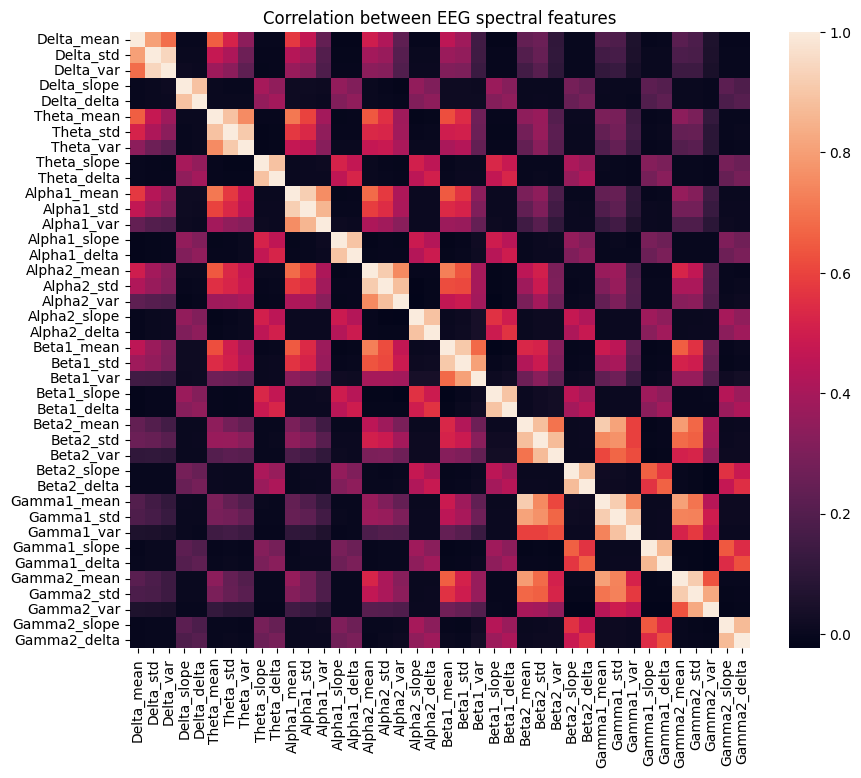

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_temp.corr())
plt.title("Correlation between EEG spectral features")
plt.show()

- EEG bands are correlated
- XGBoost can handle this dataset
- Linear models may struggle

High inter-band correlation motivates tree-based models.

In [8]:
# First XGBoost + GroupKFold

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

cv = GroupKFold(n_splits=5)
aucs = []

for train_idx, val_idx in cv.split(X_temp, y_temp, groups_temporal):
    model.fit(X_temp.iloc[train_idx], y_temp.iloc[train_idx])
    preds = model.predict_proba(X_temp.iloc[val_idx])[:,1]
    aucs.append(roc_auc_score(y_temp.iloc[val_idx], preds))

print("Temporal features (GroupCV) ROC-AUC:", np.mean(aucs))


Temporal features (GroupCV) ROC-AUC: 0.4962770463472719


### Comparison on static and temporal features

In [9]:
# baseline xgb model
baseline_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

In [10]:
 

# dataset for static features

drop_cols = [
    'SubjectID',
    'VideoID',
    'Raw',
    'predefinedlabel',
    'user-definedlabeln',
    'Attention', 'Mediation'
]

X_static = df.drop(columns=[c for c in drop_cols if c in df.columns])
#y_static= X_static['predefinedlabel']
#X_static = X_static.drop(columns='predefinedlabel')
# log transformation
for col in BANDS:
    X_static[col] = np.log1p(df[col])

y_static= df['predefinedlabel']


groups_static = df['SubjectID']


# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_static, y_static,
    test_size=0.2,
    random_state=42,
    stratify=y_static
)


baseline_xgb.fit(X_train, y_train)


y_pred = baseline_xgb.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred)
print("Static features - random split ROC-AUC:", roc_auc)



Static features - random split ROC-AUC: 0.5946166419653693


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

baseline_xgb.fit(X_train, y_train)


y_pred = baseline_xgb.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred)
print("Temporal features - random split ROC-AUC:", roc_auc)


Temporal features - random split ROC-AUC: 0.6924723949904787


In [12]:
# GroupCV evaluation function
def evaluate_model(X, y, groups, model, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)
    aucs = []

    for train_idx, val_idx in cv.split(X, y, groups):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict_proba(X.iloc[val_idx])[:, 1]
        auc = roc_auc_score(y.iloc[val_idx], preds)
        aucs.append(auc)

    return np.mean(aucs), np.std(aucs)


In [13]:
static_mean_auc, static_std_auc = evaluate_model(
    X_static,
    y_static,
    groups_static,   # SubjectID
    baseline_xgb
)

print(f"Static features GroupCV ROC-AUC: {static_mean_auc:.3f} ± {static_std_auc:.3f}")


Static features GroupCV ROC-AUC: 0.519 ± 0.039


In [14]:
temporal_mean_auc, temporal_std_auc = evaluate_model(
    X_temp,
    y_temp,
    groups_temporal,  # SubjectID
    baseline_xgb
)

print(f"Temporal features GroupCV ROC-AUC: {temporal_mean_auc:.3f} ± {temporal_std_auc:.3f}")


Temporal features GroupCV ROC-AUC: 0.500 ± 0.041


### Subject-normalized temporal features

We'll apply subject wise normalizstiom to temporal features with the goal of improving ramdom split evaluation and GroupCV performance, by removing individual EEG baselines. 

In [15]:
from sklearn.preprocessing import StandardScaler

df_temporal = pd.concat([X_temp,y_temp,groups_temporal], axis=1)
df_temporal.columns = [ 'Delta_mean',    'Delta_std',    'Delta_var',  'Delta_slope',
                      'Delta_delta',   'Theta_mean',    'Theta_std',    'Theta_var',
                      'Theta_slope',  'Theta_delta',  'Alpha1_mean',   'Alpha1_std',
                      'Alpha1_var', 'Alpha1_slope', 'Alpha1_delta',  'Alpha2_mean',
                      'Alpha2_std',   'Alpha2_var', 'Alpha2_slope', 'Alpha2_delta',
                      'Beta1_mean',    'Beta1_std',    'Beta1_var',  'Beta1_slope',
                      'Beta1_delta',   'Beta2_mean',    'Beta2_std',    'Beta2_var',
                      'Beta2_slope',  'Beta2_delta',  'Gamma1_mean',   'Gamma1_std',  
                      'Gamma1_var', 'Gamma1_slope', 'Gamma1_delta',  'Gamma2_mean',
                      'Gamma2_std',   'Gamma2_var', 'Gamma2_slope', 'Gamma2_delta',
                      'predefinedlabel','SubjectID']

df_norm = df_temporal.copy()
feature_cols = [c for c in df_norm.columns if c not in ['predefinedlabel', 'SubjectID']]

for subj in df_norm['SubjectID'].unique():
    idx = df_norm['SubjectID'] == subj
    scaler = StandardScaler()
    df_norm.loc[idx, feature_cols] = scaler.fit_transform(
        df_norm.loc[idx, feature_cols]
    )


X_temp_norm = df_norm.drop(['predefinedlabel', 'SubjectID'], axis=1)



#### Effect of subject normalization under ranndom splits:

When evaluated under a random train/validation split, subject-normalized temporal features achieve similar ROC-AUC to non-normalized features. This indicates that normalization does not remove subject-specific temporal patterns when subject overlap is present. High performance under random splits therefore reflects strong within-subject dynamics rather than subject-independent markers of confusion.

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp_norm, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

baseline_xgb.fit(X_train, y_train)


y_pred = baseline_xgb.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred)
print("Subject normalized temporal features - random split ROC-AUC:", roc_auc)


Subject normalized temporal features - random split ROC-AUC: 0.6995236145502284


#### Effect of subject normalization under GroupCV evaluation:

Contrary to expectations, normalization further reduced ROC-AUC under subject-level cross-validation, suggesting that specific subject spectral baselines contribute substantially to confusion prediction in this dataset.

In [17]:
temporal_mean_auc, temporal_std_auc = evaluate_model(
    X_temp_norm,
    y_temp,
    groups_temporal,  # SubjectID
    baseline_xgb
)

print(f"Subject normalized temporal features GroupCV ROC-AUC: {temporal_mean_auc:.3f} ± {temporal_std_auc:.3f}")

Subject normalized temporal features GroupCV ROC-AUC: 0.487 ± 0.036


### Conclusions 
Temporal aggregation of EEG spectral features substantially improved confusion classification under a random train/validation split (ROC-AUC ≈ 0.69) compared to static features (≈ 0.59), indicating strong within-subject temporal structure. Subject-wise normalization preserved this performance under random splits, suggesting that relative temporal dynamics—not absolute spectral baselines—are sufficient when subject overlap is present. However, when evaluated using subject-level cross-validation to prevent subject leakage, performance dropped to near chance for both static (≈ 0.52) and temporal features (≈ 0.50), with further degradation after subject normalization (≈ 0.49). These results indicate that confusion-related EEG signatures in this dataset are highly individualized and do not generalize across subjects when using simple spectral and temporal summary statistics. While temporal features capture meaningful within-subject dynamics, they fail to provide subject-independent markers of confusion, underscoring the importance of group-aware evaluation and highlighting the need for more expressive temporal models or subject-adaptive approaches for robust EEG-based confusion detection.